## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [2]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

Loading the Data Now, let’s load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage.

In [ ]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df_house_price = pd.read_csv(StringIO(csv_content))

# Display the first few rows
display(df_house_price.head(50))

In [ ]:
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Garage_Size         500 non-null    int64  
 5   Location_Score      500 non-null    float64
 6   Distance_to_Center  500 non-null    float64
 7   Price               500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [ ]:
df_house_price.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

Based on the above outcome we can conclude that the data is free of any null values.

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

In [ ]:
## Task 2.1. Check summary statistics for the dataset.

df_house_price.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


In [ ]:
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 11.9 MB/s eta 0:00:00


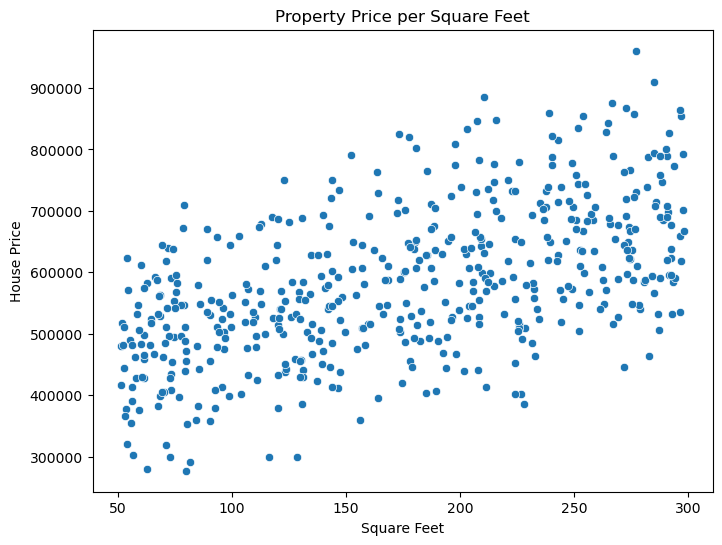

In [ ]:
## Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Square_Feet and Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Square_Feet', y='Price', data=df_house_price)
plt.title('Property Price per Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('House Price')
plt.show()

As square feet increases, house price generally increases means bigger houses usually cost more. This is called a positive correlation.

Even though the trend goes upward, the points are not in a straight line. Therefore, we can conclude that house price is 
not only dependent on square feet but also other factors.

The curve line on top (blue line) is a KDE curve (smooth distribution line) which shows the overall pattern, and it looks like a bell shape.That means the prices follow something close to a normal distribution:

a. Few houses are very cheap

b. Most house prices are concentrated around the middle range roughly between 450K to 650K

c. Few houses are very expensive

d. Prices are roughly normally distributed with a slight right tail

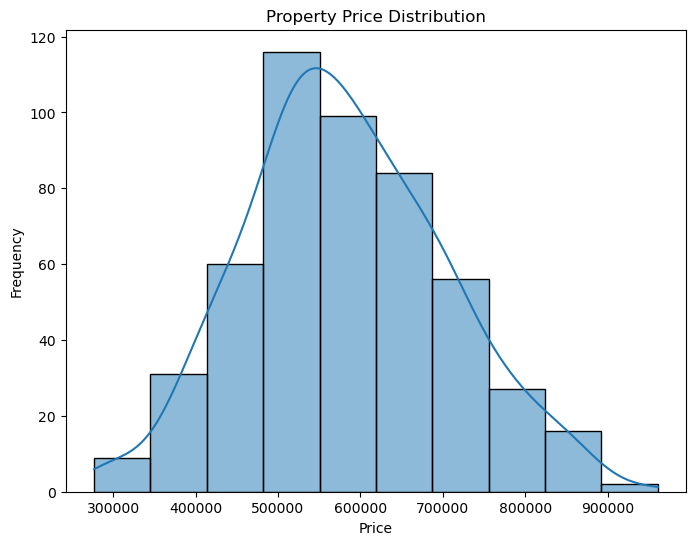

In [ ]:
## Task 2.3. Visualise the distribution of the Property Price variable using a histogram.

# Histogram for Price distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_house_price['Price'], bins=10, kde=True)
plt.title('Property Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

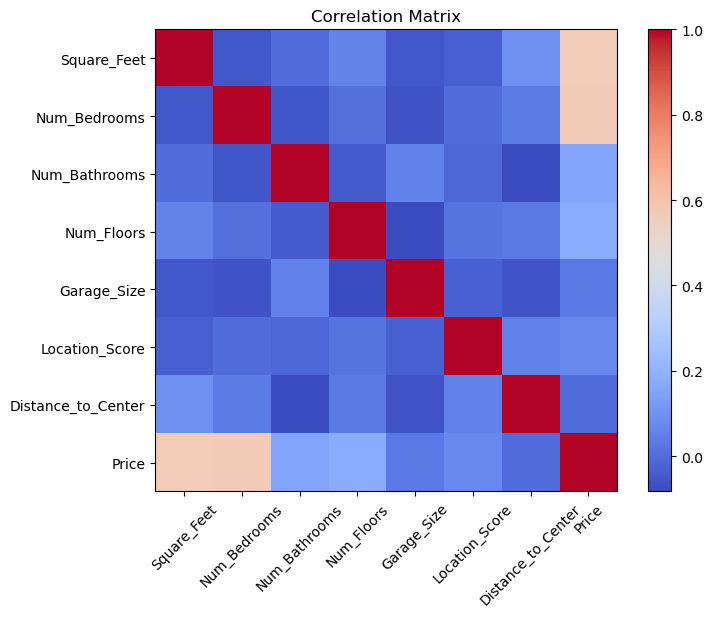

In [ ]:
## Task 2.4. Compute and visualize the correlation matrix between the features.

# Calculate the correlation matrix
correlation_matrix = df_house_price.corr()

# Heatmap of correlations using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Title and labels
plt.title('Correlation Matrix')
plt.show()


Price has strongest correlation with Square_Feet

Price also correlates with Bedrooms

Bathrooms and Floors have weak correlation with Price means Bathrooms and floors have some effect, but not strong.

Garage_Size has very weak relation with Price

Houses farther from the city center tend to have lower prices.

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

In [ ]:
## Task 3.1: Split the Data into Features and Target Split the dataset into features (X) and target variable (y).

# features (x) and target (y)
x = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price['Price']

In [ ]:
## Task 3.2: Split the Data into Training and Testing Sets Split the data into training (80%) and testing (20%) sets.

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {x_train.shape}, Testing Data: {x_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


In [ ]:
## Task 3.3: Train the Multiple Linear Regression (MLR) model using the training data.

from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model_lr = LinearRegression()

# Fit the model on the training data
model_lr.fit(x_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(x_test)

🏃 View run dynamic_basil_lr1lcbhj at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/490d77f3-9ae1-4a72-b90f-143ede00e25b/#/experiments/7a4d6589-f115-419b-aa50-1c907ba92352/runs/00a6626d-9c2b-4f2c-8937-e782eee9d28f
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/490d77f3-9ae1-4a72-b90f-143ede00e25b/#/experiments/7a4d6589-f115-419b-aa50-1c907ba92352


In [ ]:
## Task 3.4: Visualise the Predicted vs Actual Prices.

# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr
})

# Display the table
print(results_df)  # Shows the first few rows of the table

     Actual Price  Predicted Price (MLR)
361   591058.7089          525669.926934
73    667693.0003          668141.051861
374   532377.5802          467168.904743
155   478489.2990          498375.548472
104   730197.4806          691359.973840
..            ...                    ...
347   464849.9178          493645.118779
86    572360.6499          643248.170875
75    557752.8374          454235.083741
438   649930.0523          564489.566281
15    523527.9747          456453.859955

[100 rows x 2 columns]


Text(0, 0.5, 'Predicted')

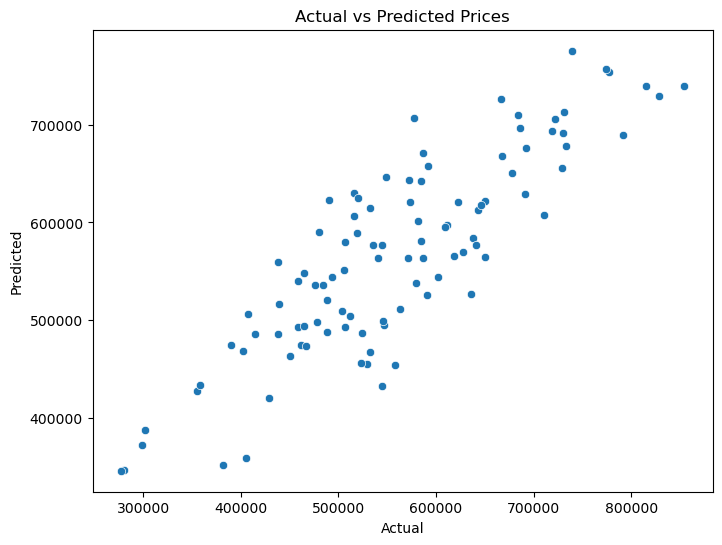

In [ ]:
## Create a scatter plot comparing the actual prices and predicted prices for the test set.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Square_Feet and Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price (MLR)', data=results_df)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual')
plt.ylabel('Predicted')

Model is performing decently well (strong positive correlation), but it’s not perfectly accurate because predictions deviate  slighty from actual values.

We will use metrics like R², MAE, or RMSE to quantify how good the predictions really are.


In [ ]:
## Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

# Calculate RMSE for MLR
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Root Mean Squared Error (RMSE) for MLR: {rmse_lr}")

Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


Multiple Linear Regression model is capturing the trend, but predictions still deviate by about 64k, meaning it’s decent but could be improved.

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

Task 4.1: Train a Random Forest Model

We will now train a Random Forest Regressor model and evaluate its performance.

In [ ]:
## Task 4.1: Train a Random Forest Model Train a Random Forest Regressor model and evaluate its performance.

from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Fit the Random Forest model on the training data
model_rf.fit(x_train, y_train)

# Make predictions on the test data
y_pred_rf = model_rf.predict(x_test)

🏃 View run nifty_curtain_7d1sqnjd at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/490d77f3-9ae1-4a72-b90f-143ede00e25b/#/experiments/7a4d6589-f115-419b-aa50-1c907ba92352/runs/5358f846-0926-4e34-97b0-955734cc8ab8
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/490d77f3-9ae1-4a72-b90f-143ede00e25b/#/experiments/7a4d6589-f115-419b-aa50-1c907ba92352


In [ ]:
## Task 4.2: Visualise Actual vs Predicted Prices for Random Forest

# Create a table with Actual vs Predicted Prices for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df_rf.head())

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500627.243247
73    667693.0003                    654256.956307
374   532377.5802                    561434.354749
155   478489.2990                    484593.849958
104   730197.4806                    757536.282477


Text(0, 0.5, 'Predicted')

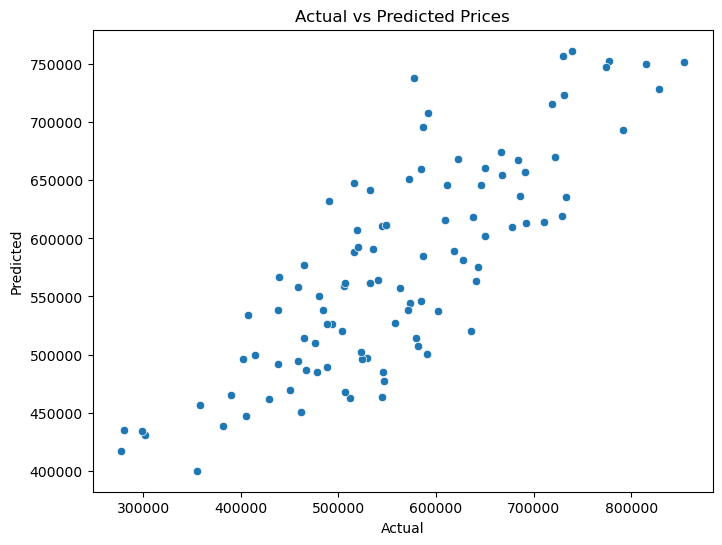

In [ ]:
## Task 4.2: Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Square_Feet and Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price (Random Forest)', data=results_df_rf)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual')
plt.ylabel('Predicted')

In Scatter plot, dots are not spread randomly. They are clearly moving upward.

That means Random Forest is capturing the trend. It has learned the price trend well.

We will use metrics RMSE to quantify how good the predictions really are.

In [ ]:
## Task 4.3: Model Comparison Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

# Calculate RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

Root Mean Squared Error (RMSE) for Random Forest: 72013.1303207925


Root Mean Squared error tells us on average, how far my model’s predictions are from the real price. In this case ,model is typically off by about $72,013 per house.

In [ ]:
# Compare the RMSE of both models
print(f"RMSE for MLR: {rmse_lr}")
print(f"RMSE for Random Forest: {rmse_rf}")

# Provide insights
if rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model performs better based on RMSE.")

RMSE for MLR: 63952.37599755184
RMSE for Random Forest: 72013.1303207925
The Multiple Linear Regression model performs better based on RMSE.


## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

 Exploratory Data Analysis (EDA): We explored the dataset, visualised key features, and examined correlations to understand the factors influencing houses Price


 Multiple Linear Regression (MLR): We built the  MLR model to predict prices, and evaluated it using Root Mean Squared Error (RMSE). Since RMSE measures the average prediction error, the lower value indicates that the Linear Regression model made predictions closer to the actual house prices.The scatter plot also supports this result.

 Random Forest Regressor: The Random Forest model appears to underestimate some high-priced houses, which increases prediction error and contributes to the higher RMSE.

 Model Evaluation: RMSE helped us compare model performances, and we saw that Multiple linear regression was more effective for this dataset.

Key Insight: The dataset may have strong linear relationships between features (such as square footage) and house price.
Linear Regression handles these direct relationships efficiently.
Random Forest, without tuning, may struggle with predicting extreme values and often produces averaged predictions, leading to underestimation of high-value houses.

Improvements : We can improve the Random Forest model by increasing dataset size, as Random Forest performs better with larger datasets. 

This exercise highlights the importance of model evaluation, feature exploration, and choosing the right model for your data.


Excellent work on this submission.

Your code is well organised, and the insights you extracted are clear, relevant, and supported by the outputs. The analysis demonstrates a strong understanding of the data and great attention to detail.

To make it even more professional, I recommend adding clear section titles (in bold) before each explanation. This would improve readability, structure the narrative more effectively, and make the notebook presentation stronger overall.

Very well done. Jose